In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime, json, os

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'/nfs/dataset'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [14]:
# plot the distribution of shareGPT and L-Eval
def plot_distribution(json_data_path, dataset_name):
    try:
        # 尝试读取 JSON 数据
        with open(json_data_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error reading JSON file: {e}")
        return

    human_lengths = []
    gpt_lengths = []

    # 遍历数据以提取文本长度
    for item in data:
        conversations = item.get('conversations', [])
        for conversation in conversations:
            text = conversation.get('value', '')
            if text:  # 检查文本是否非空
                # print(f"Text: {text}")
                length = len(text)
                # print(f'length is {length}')
                if conversation['from'] == 'human':
                    if 'sharegpt' in dataset_name:
                        if length > 4096:
                            continue
                    human_lengths.append(length)
                elif conversation['from'] == 'gpt':
                    if 'sharegpt' in dataset_name:
                        if length > 5000:
                            continue                    
                    gpt_lengths.append(length)

    # print("Human value lengths:", human_lengths)
    # print("GPT value lengths:", gpt_lengths)

    # 计算统计指标
    human_mean = np.mean(human_lengths) if human_lengths else 0
    human_median = np.median(human_lengths) if human_lengths else 0
    human_std = np.std(human_lengths) if human_lengths else 0
    human_max = max(human_lengths) if human_lengths else 0

    gpt_mean = np.mean(gpt_lengths) if gpt_lengths else 0
    gpt_median = np.median(gpt_lengths) if gpt_lengths else 0
    gpt_std = np.std(gpt_lengths) if gpt_lengths else 0
    gpt_max = max(gpt_lengths) if gpt_lengths else 0

    print(f"Human lengths - Mean: {human_mean:.2f}, Median: {human_median:.2f}, Std: {human_std:.2f}")
    print(f"GPT lengths - Mean: {gpt_mean:.2f}, Median: {gpt_median:.2f}, Std: {gpt_std:.2f}")

    # 绘制分布图
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # 绘制CDF
    sns.kdeplot(human_lengths, cumulative=False, color=plt.cm.tab20b(0/4), linestyle='-', linewidth=1.5, label=f'Input (Avg:{human_mean:.0f})', alpha=0.5, fill=True)
    sns.kdeplot(gpt_lengths, cumulative=False, color=plt.cm.tab20b(1/4), linestyle='-', linewidth=1.5, label=f'Output (Avg:{gpt_mean:.0f})', alpha=0.5, fill=True)

    # 标记出最大值
    if 'sharegpt' == dataset_name: 
        input_max_label = 0.0015
        output_max_label = 0.0025
    if 'LEval' == dataset_name: 
        input_max_label = 0.0001
        output_max_label = 0.0002
    ax.annotate(f'Max: {human_max}', xy=(human_max, 0), xytext=(human_max, input_max_label),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=8, color=plt.cm.tab20b(0/4), ha='center')
    ax.annotate(f'Max: {gpt_max}', xy=(gpt_max, 0), xytext=(gpt_max, output_max_label),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=8, color=plt.cm.tab20b(1/4), ha='center')

    ax.set_ylabel('Density')
    ax.set_xlabel('Length')
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.33, 0.53), ncol=1, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/{dataset_name}_distribution.pdf', bbox_inches='tight')
    # plt.close()


Human lengths - Mean: 221.80, Median: 78.00, Std: 464.69
GPT lengths - Mean: 1346.09, Median: 1240.00, Std: 901.46
Human lengths - Mean: 35955.70, Median: 29286.00, Std: 15648.91
GPT lengths - Mean: 5188.70, Median: 5377.00, Std: 858.58


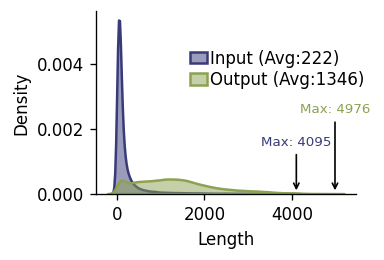

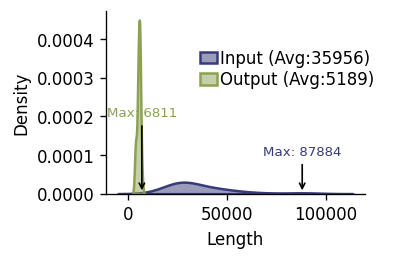

In [15]:
sharegpt_path = f'{DATASET_PATH}/ShareGPT_V3_unfiltered_cleaned_split.json'
Leval_paper_assistant_path = f'{DATASET_PATH}/LEval/LEval-data/Open-ended-tasks/paper_assistant_transformed.json'
plot_distribution(sharegpt_path, 'sharegpt')
plot_distribution(Leval_paper_assistant_path, 'LEval')